<center>Universidade Federal de Viçosa</center>
<center>Coordenadoria de Educação Aberta e a Distância</center>
<center>Inteligência Artificial e Computacional</center>
<center>ELT578 - Análise de Imagens e Visão Computacional</center>

**<center>AULA PRÁTICA 5: Espaços de Cores</center>**

* Entender o conceito de diferentes espaços de cores e suas aplicações.

* Aprender a converter entre espaços de cores usando OpenCV.

**1) Montando o Google Drive**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

**2) Importando bibliotecas**

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


**3) Conversão entre espaços de cores**

* **RGB:** captura e visualização.

* **HSV:** robusto para detecção de cores (separa intensidade de cor).

* **YUV:** usado em ajustes de cor e correção de iluminação.


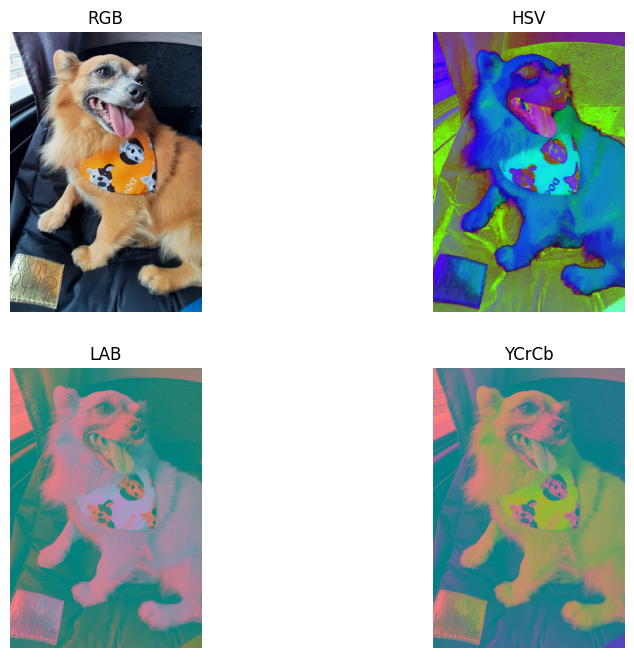

In [14]:
img = cv2.imread(r'/home/usuario/second-brain/UFV/578-AnalisedeImagenseVisaoComputacional/Docs/images/dog.jpeg')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

titles = ['RGB', 'HSV', 'LAB', 'YCrCb']
images = [img_rgb, img_hsv, img_lab, img_ycrcb]

plt.figure(figsize=(10,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')
plt.show()

**4) Detecção de cor com HSV**

* H (Hue) → Matiz, representa a cor pura na forma de um ângulo em um círculo cromático (0 a 360° no modelo teórico, mas no OpenCV vai de 0 a 179).

* S (Saturation) → Saturação, intensidade da cor. 0 = tons de cinza, 255 = cor vibrante

* V (Value) → Valor, brilho (quão claro ou escuro). 0 = preto, 255 = brilho máximo

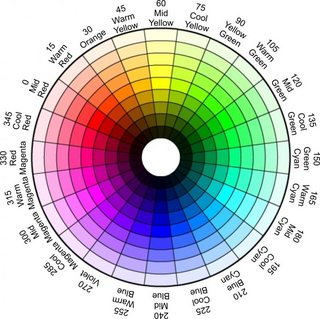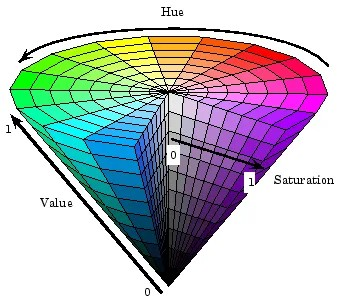

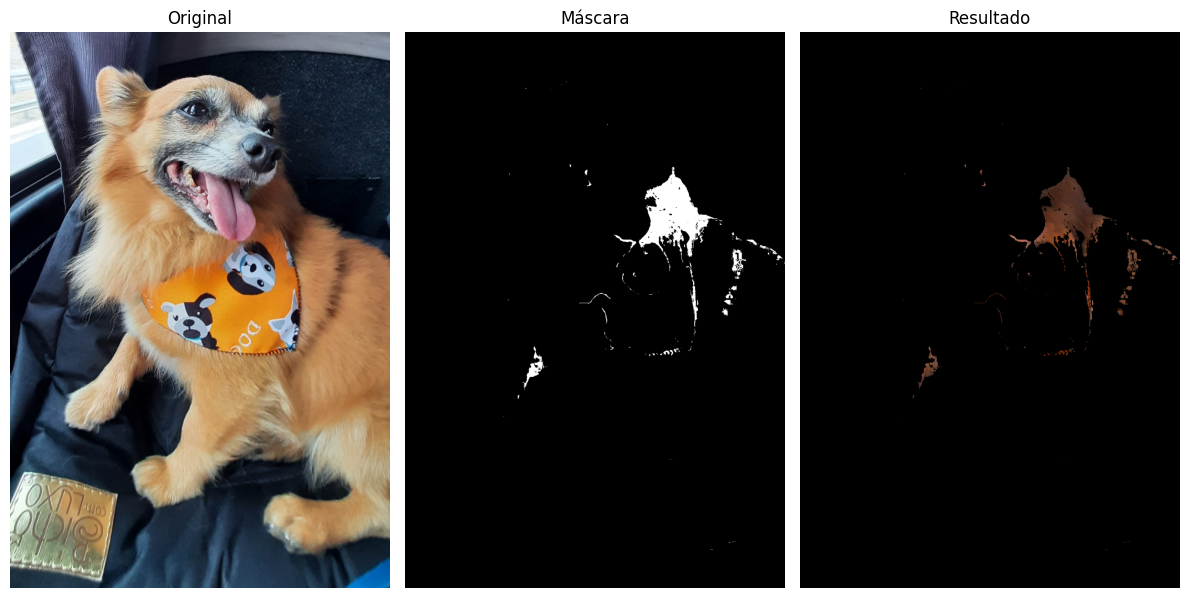

In [19]:
img = cv2.imread(r'/home/usuario/second-brain/UFV/578-AnalisedeImagenseVisaoComputacional/Docs/images/dog.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower = np.array([0, 90, 60])
upper = np.array([10, 255, 255])

mask = cv2.inRange(hsv, lower, upper)
res = cv2.bitwise_and(img, img, mask=mask)
res_rgb = cv2.cvtColor(res, cv2.COLOR_BGR2RGB)
titles = ['Original', 'Máscara', 'Resultado']
images = [img_rgb, mask, res_rgb]

# Exibir lado a lado com for
plt.figure(figsize=(12, 6))
for i in range(3):
    plt.subplot(1, 3, i+1)
    if titles[i] == 'Máscara':
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()
#cv2_imshow(img)


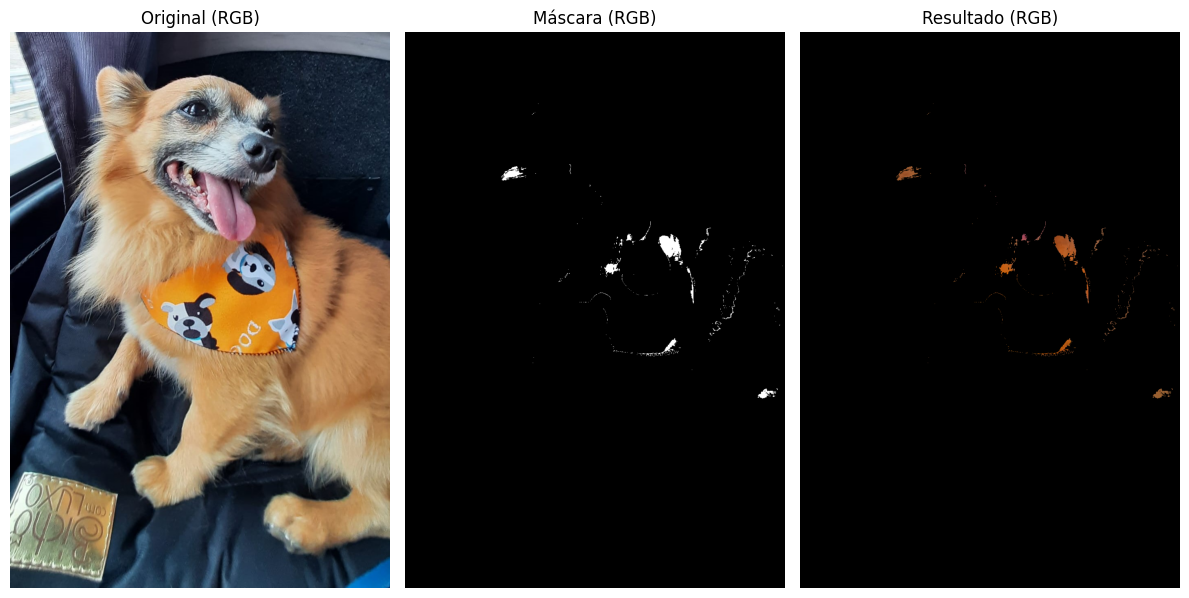

In [16]:
img = cv2.imread(r'/home/usuario/second-brain/UFV/578-AnalisedeImagenseVisaoComputacional/Docs/images/dog.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Intervalo para a cor vermelha no espaço RGB
# (valores ajustados para evitar pegar tons muito escuros ou muito claros)
lower_rgb = np.array([150, 0, 0])   # vermelho escuro
upper_rgb = np.array([255, 100, 100])  # vermelho claro

# Criar máscara no espaço RGB
mask_rgb = cv2.inRange(img_rgb, lower_rgb, upper_rgb)
res_rgb_mask = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_rgb)

# Exibir lado a lado (Original, Máscara, Resultado)
titles = ['Original (RGB)', 'Máscara (RGB)', 'Resultado (RGB)']
images = [img_rgb, mask_rgb, res_rgb_mask]

plt.figure(figsize=(12, 6))
for i in range(3):
    plt.subplot(1, 3, i+1)
    if i == 1:  # Máscara em escala de cinza
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

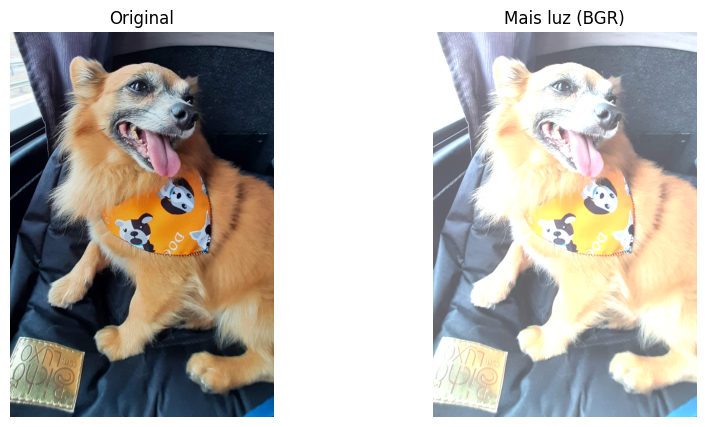

True

In [18]:
img = cv2.imread(r'/home/usuario/second-brain/UFV/578-AnalisedeImagenseVisaoComputacional/Docs/images/dog.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Aumentar brilho adicionando um valor
brilho = 100  # quanto maior, mais claro
img_brighter = cv2.add(img_rgb, np.array([brilho, brilho, brilho], dtype=np.uint8))

# Exibir original e imagem com mais luz
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_brighter)
plt.title('Mais luz (BGR)')
plt.axis('off')
plt.show()

# Salvar no formato original (BGR)
cv2.imwrite('/home/usuario/second-brain/UFV/578-AnalisedeImagenseVisaoComputacional/Docs/images/dog_brighter.jpeg',
            cv2.cvtColor(img_brighter, cv2.COLOR_RGB2BGR))